In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import process_data as pd

COHERENT ONLY PLOTS:

In [3]:
coherent = pd.make_data_dictionary("../results/coherent_only_run.csv", "../results/51-full_QKE-eps.csv")
coherent.keys()

dict_keys(['time', 'N_bins', 'rho', 'rhobar', 'f', 'Tcm', 'eps', 'w', 'dnde'])

In [4]:
P0, Px, Py, Pz = pd.make_P(coherent['rho'])

In [5]:
V_coherent = pd.V_mat(coherent)

In [6]:
t = coherent['time']
Vy = V_coherent[1,:]
dy = np.diff(Vy)

In [7]:
#finding indices for zero, min, max, zero for coherent only run

tlist = []
Vylist = []

for i in range(len(Vy)-2):
    
    if Vy[i]*Vy[i+1] <= 0:
        tlist.append(i)
        Vylist.append(i)
    if dy[i]*dy[i+1] < 0:
        tlist.append(i)
        Vylist.append(i)

t_index = np.array(tlist)
Vy_index = np.array(Vylist)

([<matplotlib.axis.YTick at 0x14a144b50>,
 [Text(0, -200, '$-200$'),
  Text(0, -100, '$-100$'),
  Text(0, 0, '$0$'),
  Text(0, 100, '$100$'),
  Text(0, 200, '$200$')])

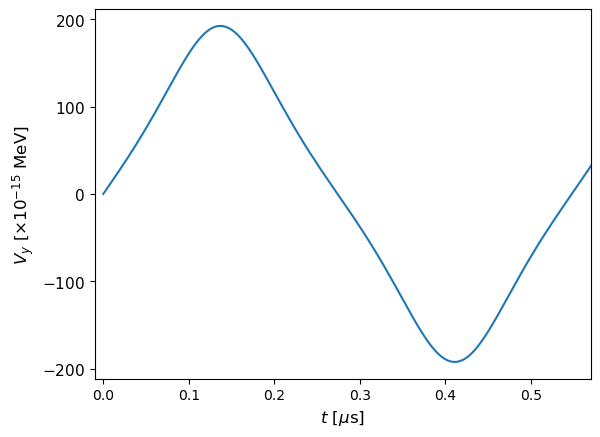

In [8]:
#plot first cycle of Vy vs t for coherent only run

plt.figure()
#plt.scatter(t[t_index][0:5], Vy[Vy_index[0:5]]*1e15)
plt.plot(t[t_index[0] : t_index[5]], Vy[Vy_index[0] : Vy_index[5]]*1e15)
plt.xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
plt.ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=12)
plt.xlim([-0.01,0.57])
plt.yticks([-200, -100, 0, 100, 200], [r"$-200$",r"$-100$",r"$0$",r"$100$",r"$200$"], fontsize=11)
#plt.title("Vy vs t (coherent only, first cycle)")

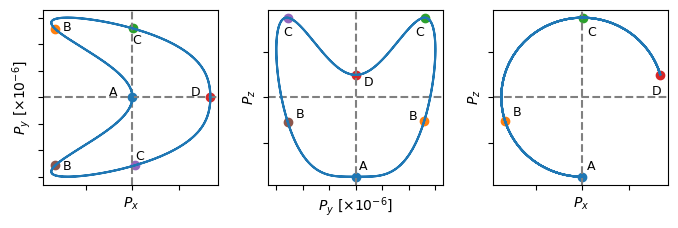

In [9]:
fig = plt.figure(figsize=(7,2.5))

array = ([0, 27, 48, 70, 90, 111])
xy1 = fig.add_axes([2/28, 1/10, 7/28, 7/10])
yz1 = fig.add_axes([11/28, 1/10, 7/28, 7/10])
xz1 = fig.add_axes([20/28, 1/10, 7/28, 7/10])

bloch = [xy1, yz1, xz1]

for ax in bloch:
    ax.axhline(0, c='0.50', ls='--')
    ax.axvline(0, c='0.50', ls='--')

label_fontsize = 10

xy1.plot(Px[t_index[0] : t_index[8],15], Py[t_index[0] : t_index[8],15]*1e6)
xy1.scatter(Px[0,15], Py[t_index[0],15]*1e6)
xy1.scatter(Px[27,15], Py[27,15]*1e6)
xy1.scatter(Px[48,15], Py[48,15]*1e6)
xy1.scatter(Px[70,15], Py[70,15]*1e6)
xy1.scatter(Px[90,15], Py[90,15]*1e6)
xy1.scatter(Px[111,15], Py[111,15]*1e6)
xy1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy1.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy1.set_xticks([-0.2, 0, 0.2])
xy1.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
xy1.tick_params(labelbottom=False, labelleft=False) 
xy1.text(-0.1,0.01, "A", fontsize=9)
xy1.text(-0.3,0.5, "B", fontsize=9)
xy1.text(0,0.4, "C", fontsize=9)
xy1.text(0.25,0.01, "D", fontsize=9)
xy1.text(0.01,-0.475, "C", fontsize=9)
xy1.text(-0.3,-0.55, "B", fontsize=9)

yz1.plot(Py[t_index[0] : t_index[8],15]*1e6, Pz[t_index[0] : t_index[8],15])
yz1.scatter(Py[0,15]*1e6, Pz[0,15])
yz1.scatter(Py[27,15]*1e6, Pz[27,15])
yz1.scatter(Py[48,15]*1e6, Pz[48,15])
yz1.scatter(Py[70,15]*1e6, Pz[70,15])
yz1.scatter(Py[90,15]*1e6, Pz[90,15])
yz1.scatter(Py[111,15]*1e6, Pz[111,15])
yz1.set_xlabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
yz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
yz1.set_yticks([-0.2, 0, 0.2])
yz1.set_xticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
yz1.tick_params(labelbottom=False, labelleft=False) 
yz1.text(0.02,-0.32, "A", fontsize=9)
yz1.text(0.4,-0.1, "B", fontsize=9)
yz1.text(0.45,0.27, "C", fontsize=9)
yz1.text(0.06,0.05, "D", fontsize=9)
yz1.text(-0.55,0.27, "C", fontsize=9)
yz1.text(-0.45,-0.09, "B", fontsize=9)

xz1.plot(Px[t_index[0] : t_index[8],15], Pz[t_index[0] : t_index[8],15])
xz1.scatter(Px[0,15], Pz[0,15])
xz1.scatter(Px[27,15], Pz[27,15])
xz1.scatter(Px[48,15], Pz[48,15])
xz1.scatter(Px[70,15], Pz[70,15])
xz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz1.set_yticks([-0.2, 0, 0.2])
xz1.set_yticks([-0.2, 0, 0.2])
xz1.tick_params(labelbottom=False, labelleft=False) 
xz1.text(0.02,-0.32, "A", fontsize=9)
xz1.text(-0.3,-0.08, "B", fontsize=9)
xz1.text(0.02,0.27, "C", fontsize=9)
xz1.text(0.3,0.01, "D", fontsize=9)

plt.savefig("CoherentBloch.pdf", bbox_inches='tight')

Text(0, 0.5, '$P_x$')

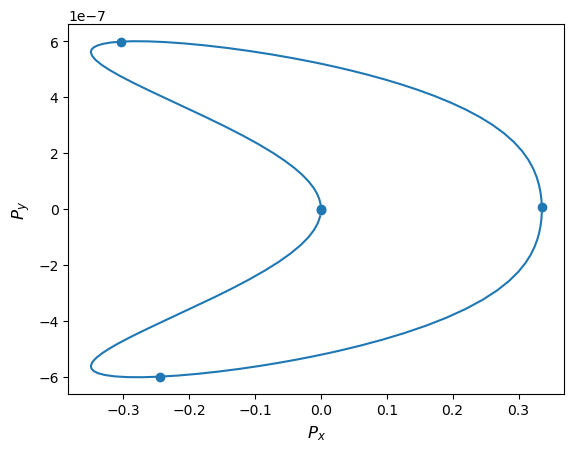

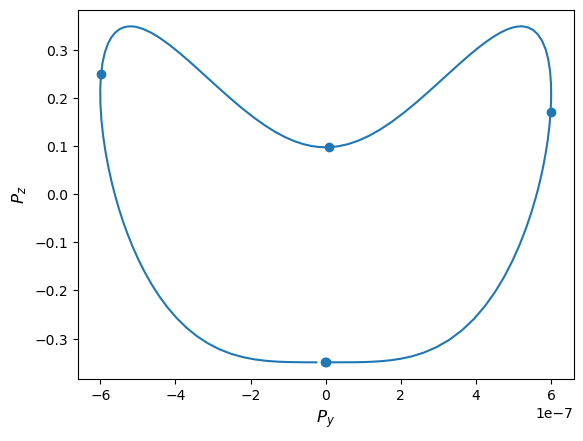

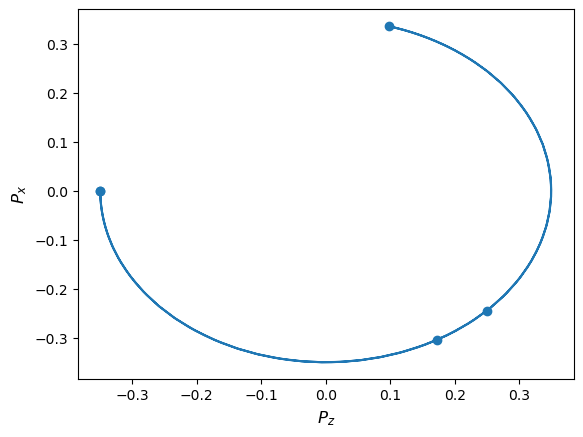

In [10]:
#plot FIRST CYCLE of bloch sphere for coherent only

plt.figure()
plt.scatter(Px[t_index,15][0:5], Py[t_index,15][0:5])
plt.plot(Px[t_index[0] : t_index[4],15], Py[t_index[0] : t_index[4],15])
plt.xlabel(r"$P_x$", fontsize=12)
plt.ylabel(r"$P_y$", fontsize=12)
#plt.title("Py vs Px (coherent only, first cycle)")

plt.figure()
plt.scatter(Py[t_index,15][0:5], Pz[t_index,15][0:5])
plt.plot(Py[t_index[0] : t_index[4],15], Pz[t_index[0] : t_index[4],15])
plt.xlabel(r"$P_y$", fontsize=12)
plt.ylabel(r"$P_z$", fontsize=12)
#plt.title("Pz vs Py (coherent only, first cycle)")

plt.figure()
plt.scatter(Pz[t_index,15][0:5], Px[t_index,15][0:5])
plt.plot(Pz[t_index[0] : t_index[4],15], Px[t_index[0] : t_index[4],15])
plt.xlabel(r"$P_z$", fontsize=12)
plt.ylabel(r"$P_x$", fontsize=12)
#plt.title("Px vs Pz (coherent only, first cycle)")

Text(0, 0.5, '$P_x$')

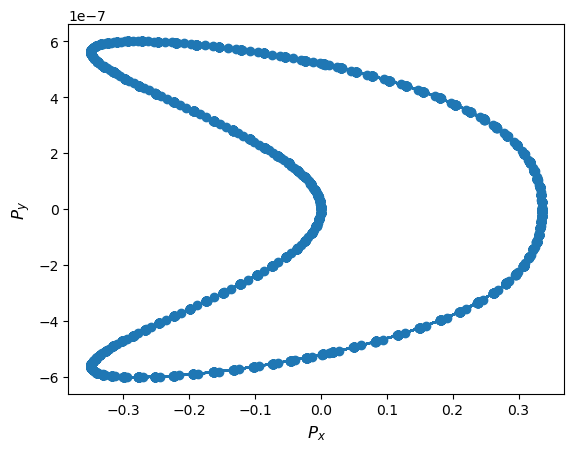

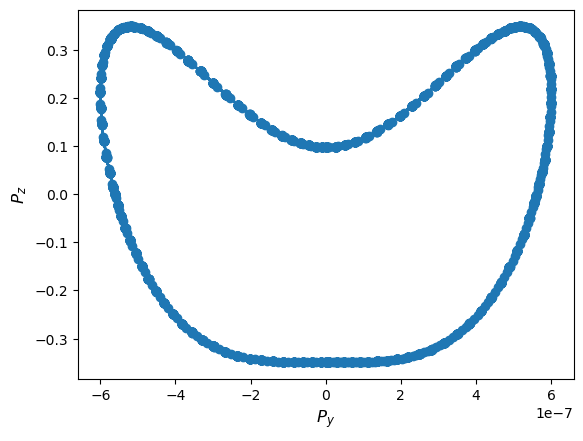

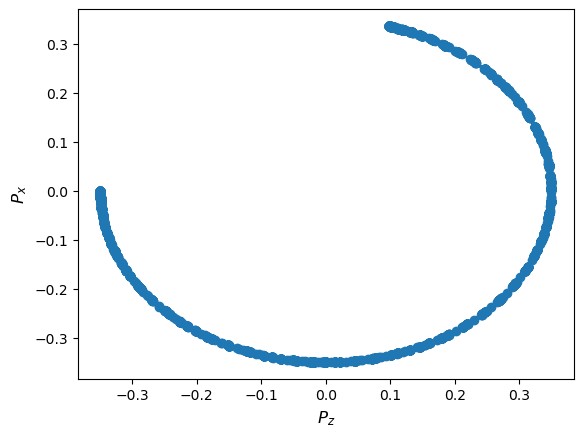

In [11]:
#Bloch Sphere evolution for coherent only ALL CYCLES

plt.figure()
plt.scatter(Px[:,15], Py[:,15])
plt.plot(Px[:,15], Py[:,15])
plt.xlabel(r"$P_x$", fontsize=12)
plt.ylabel(r"$P_y$", fontsize=12)
#plt.title("Py vs Px (coherent only, all cycles)")

plt.figure()
plt.scatter(Py[:,15],Pz[:,15])
plt.plot(Py[:,15],Pz[:,15])
plt.xlabel(r"$P_y$", fontsize=12)
plt.ylabel(r"$P_z$", fontsize=12)
#plt.title("Pz vs Py (coherent only, all cycles)")

plt.figure()
plt.scatter(Pz[:,15],Px[:,15])
plt.plot(Pz[:,15],Px[:,15])
plt.xlabel(r"$P_z$", fontsize=12)
plt.ylabel(r"$P_x$", fontsize=12)
#plt.title("Px vs Pz (coherent only, all cycles)")

FULL QKE PLOTS:

In [13]:
QKE = pd.make_data_dictionary("../results/62-fix_mat_small.csv", "../results/51-full_QKE-eps.csv")
QKE.keys()

dict_keys(['time', 'N_bins', 'rho', 'rhobar', 'f', 'Tcm', 'eps', 'w', 'dnde'])

In [14]:
P0, Px, Py, Pz = pd.make_P(QKE['rho'])

In [15]:
V_QKE = pd.V_mat(QKE)

In [16]:
t = QKE['time']
Vy = V_QKE[1,:]
dy = np.diff(Vy)

In [17]:
#Finding indices for zero, min, zero, max points (QKE)

tlist = []
Vylist = []

for i in range(len(Vy)-2):
    
    if Vy[i]*Vy[i+1] <= 0:
        tlist.append(i)
        Vylist.append(i)
    if dy[i]*dy[i+1] < 0:
        tlist.append(i)
        Vylist.append(i)

t_index = np.array(tlist)
Vy_index = np.array(Vylist)

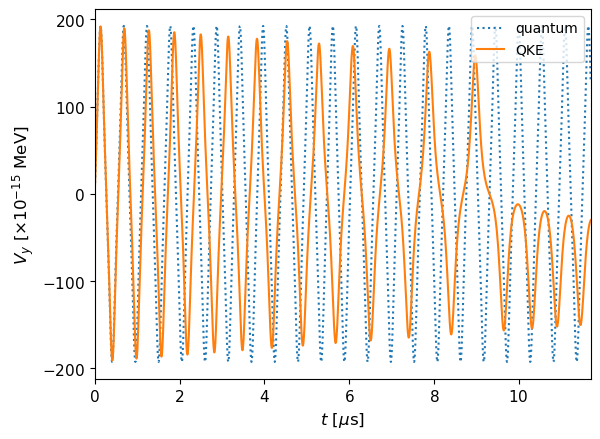

In [18]:
#QKE and coherent Vy comparison: This figure will go in preceding section, but referred to when comparing Vy for quantum vs QKE solutions

plt.figure()
plt.plot(coherent['time'], V_coherent[1,:]*1e15, ls=":", label="quantum")
plt.plot(QKE['time'], V_QKE[1,:]*1e15, label="QKE")
plt.xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
plt.ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=12)
plt.xticks([0,2,4,6,8,10],[r"$0$",r"$2$",r"$4$",r"$6$",r"$8$",r"$10$"], fontsize=11)
plt.yticks([-200, -100, 0, 100, 200], [r"$-200$",r"$-100$",r"$0$",r"$100$",r"$200$"], fontsize=11)
plt.xlim(0, 11.7)
plt.legend(loc= 'upper right')
plt.savefig("vxyz.pdf", bbox_inches='tight')
plt.show()

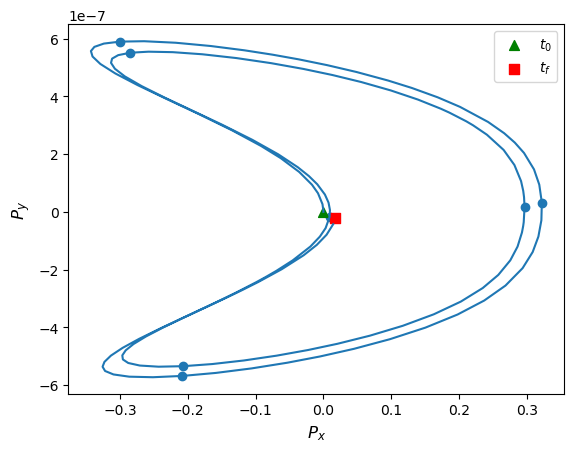

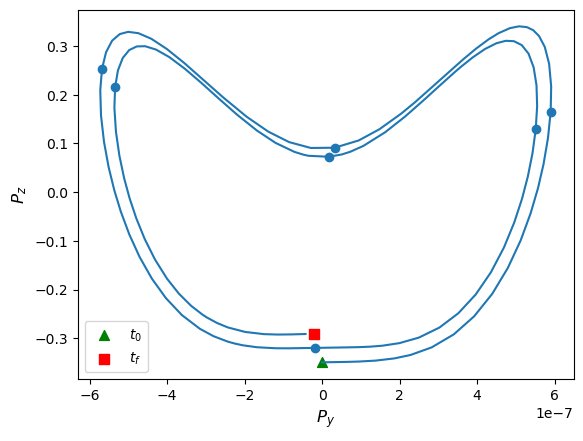

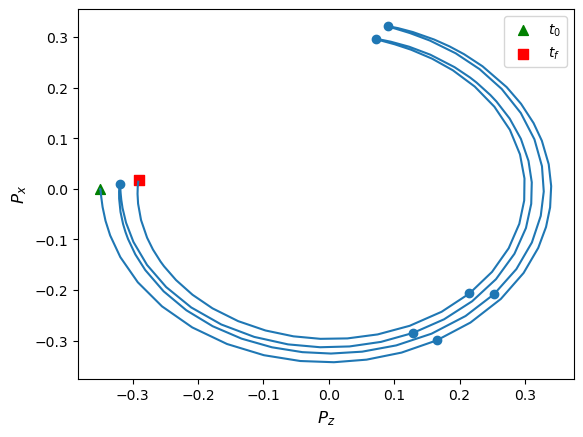

In [19]:
#Bloch Sphere plots for first 2 cycles (QKE)

plt.figure()
plt.scatter(Px[t_index,15][1:9], Py[t_index,15][1:9])
plt.scatter(Px[t_index,15][0],Py[t_index,15][0], marker='^', color='green', s=50, label=r"$t_0$")
plt.scatter(Px[t_index,15][8],Py[t_index,15][8], marker='s', color='red', s=50, label=r"$t_f$")
plt.plot(Px[t_index[0] : t_index[8],15], Py[t_index[0] : t_index[8],15])
plt.xlabel(r"$P_x$", fontsize=12)
plt.ylabel(r"$P_y$", fontsize=12)
plt.legend()
#plt.title("Py vs Px (full QKE, first two cycles)")

plt.figure()
plt.scatter(Py[t_index,15][1:9], Pz[t_index,15][1:9])
plt.scatter(Py[t_index,15][0],Pz[t_index,15][0], marker='^', color='green', s=50, label=r"$t_0$")
plt.scatter(Py[t_index,15][8],Pz[t_index,15][8], marker='s', color='red', s=50, label=r"$t_f$")
plt.plot(Py[t_index[0] : t_index[8],15], Pz[t_index[0] : t_index[8],15])
plt.xlabel(r"$P_y$", fontsize=12)
plt.ylabel(r"$P_z$", fontsize=12)
plt.legend()
#plt.title("Pz vs Py (full QKE, first two cycles)")

plt.figure()
plt.scatter(Pz[t_index,15][1:9],Px[t_index,15][1:9])
plt.scatter(Pz[t_index,15][0],Px[t_index,15][0], marker='^', color='green', s=50, label=r"$t_0$")
plt.scatter(Pz[t_index,15][8],Px[t_index,15][8], marker='s', color='red', s=50, label=r"$t_f$")
plt.plot(Pz[t_index[0] : t_index[8],15], Px[t_index[0] : t_index[8],15])
plt.xlabel(r"$P_z$", fontsize=12)
plt.ylabel(r"$P_x$", fontsize=12)
plt.legend()
#plt.title("Px vs Pz ((full QKE, first two cycles)")

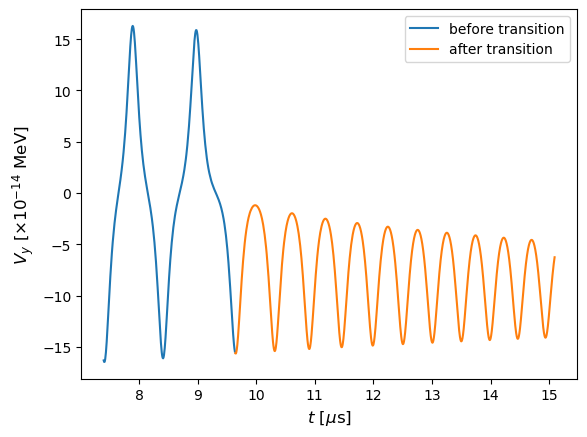

In [20]:
plt.figure()
#plt.scatter(t[t_index][43:51], Vy[Vy_index][43:51]*1e14)
plt.plot(t[t_index[43]:t_index[51]], Vy[Vy_index[43]:Vy_index[51]]*1e14, label=r"before transition")
plt.xlabel(r"$t~[\mu\text{s}]$", fontsize=12)
plt.ylabel(r"$V_y~[\times 10^{-14}~\text{MeV}]$", fontsize=12)
#plt.scatter(t[t_index][51:], Vy[Vy_index][51:]*1e14)
plt.plot(t[t_index[51] :], Vy[Vy_index[51] :]*1e14, label=r"after transition")
plt.legend()

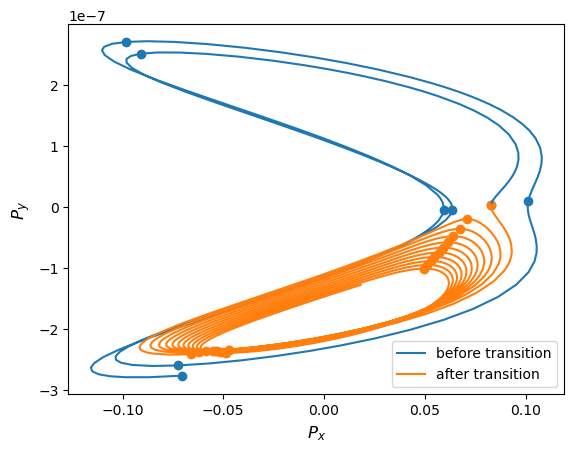

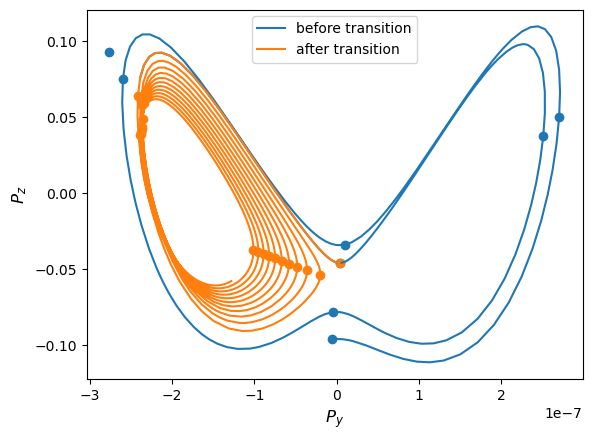

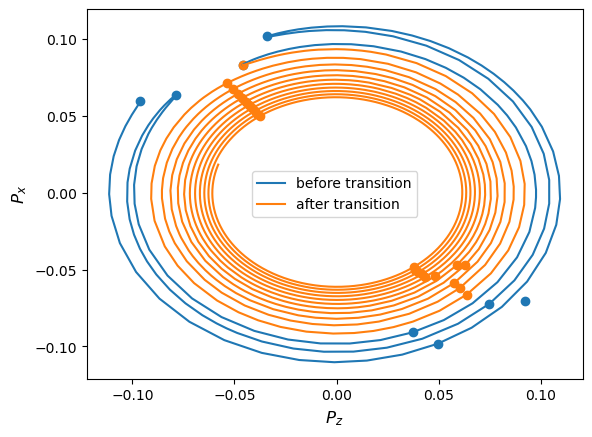

In [21]:
#just before and just after transition on same plot, QKE

plt.figure()
plt.scatter(Px[t_index,15][43:51], Py[t_index,15][43:51])
plt.plot(Px[t_index[43]:t_index[50],15], Py[t_index[43]:t_index[50],15],  label=r"before transition")
plt.scatter(Px[t_index,15][50:], Py[t_index,15][50:])
plt.plot(Px[t_index[50]:,15], Py[t_index[50]:,15],  label=r"after transition")
plt.xlabel(r"$P_x$", fontsize=12)
plt.ylabel(r"$P_y$", fontsize=12)
plt.legend()


plt.figure()
plt.scatter(Py[t_index,15][43:51], Pz[t_index,15][43:51])
plt.plot(Py[t_index[44]:t_index[51],15], Pz[t_index[44]:t_index[51],15], label=r"before transition")
plt.scatter(Py[t_index,15][50:], Pz[t_index,15][50:])
plt.plot(Py[t_index[50]:,15], Pz[t_index[50]:,15], label=r"after transition")
plt.xlabel(r"$P_y$", fontsize=12)
plt.ylabel(r"$P_z$", fontsize=12)
plt.legend()

plt.figure()
plt.scatter(Pz[t_index,15][43:51],Px[t_index,15][43:51])
plt.plot(Pz[t_index[44]:t_index[50],15], Px[t_index[44]:t_index[50],15], label=r"before transition")
plt.scatter(Pz[t_index,15][50:], Px[t_index,15][50:])
plt.plot(Pz[t_index[50]:,15], Px[t_index[50]:,15], label=r"after transition")
plt.xlabel(r"$P_z$", fontsize=12)
plt.ylabel(r"$P_x$", fontsize=12)
plt.legend()

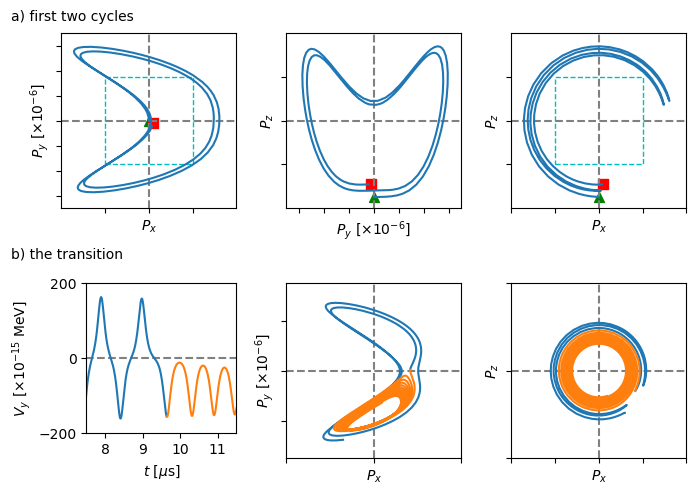

In [22]:
fig = plt.figure(figsize=(7,5))
subfigs = fig.subfigures(nrows=2, ncols=1, hspace=0)

xy1 = subfigs[0].add_axes([2/28, 1/10, 7/28, 7/10])
yz1 = subfigs[0].add_axes([11/28, 1/10, 7/28, 7/10])
xz1 = subfigs[0].add_axes([20/28, 1/10, 7/28, 7/10])

xy2 = subfigs[1].add_axes([11/28, 1/10, 7/28, 7/10])
xz2 = subfigs[1].add_axes([20/28, 1/10, 7/28, 7/10])

xy2.set_box_aspect(1)
xz2.set_box_aspect(1)

V2 = subfigs[1].add_axes([3/28, 2/10, 6/28, 6/10])

V2.axhline(0, c='0.50', ls='--')

bloch = [xy1, yz1, xz1, xy2, xz2]

for ax in bloch:
    ax.axhline(0, c='0.50', ls='--')
    ax.axvline(0, c='0.50', ls='--')

label_fontsize = 10

#xy1.scatter(Px[t_index,15][1:9], Py[t_index,15][1:9]*1e6)
xy1.scatter(Px[t_index,15][0],Py[t_index,15][0]*1e6, marker='^', color='green', s=50, label=r"$t_0$")
xy1.scatter(Px[t_index,15][8],Py[t_index,15][8]*1e6, marker='s', color='red', s=50, label=r"$t_f$")
xy1.plot(Px[t_index[0] : t_index[8],15], Py[t_index[0] : t_index[8],15]*1e6)
xy1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy1.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy1.set_xticks([-0.2, 0, 0.2])
xy1.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
xy1.tick_params(labelbottom=False, labelleft=False)
xy1.set_xlim(-0.4,0.4)
xy1.set_ylim(-0.7,0.7)
xy1.add_patch(plt.Rectangle((-.2, -.35), .4, .7, ls="--", fc="none", ec="c"))

#yz1.scatter(Py[t_index,15][1:9]*1e6, Pz[t_index,15][1:9])
yz1.scatter(Py[t_index,15][0]*1e6,Pz[t_index,15][0], marker='^', color='green', s=50, label=r"$t_0$")
yz1.scatter(Py[t_index,15][8]*1e6,Pz[t_index,15][8], marker='s', color='red', s=50, label=r"$t_f$")
yz1.plot(Py[t_index[0] : t_index[8],15]*1e6, Pz[t_index[0] : t_index[8],15])
yz1.set_xlabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
yz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
yz1.set_yticks([-0.2, 0, 0.2])
yz1.set_xticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
yz1.tick_params(labelbottom=False, labelleft=False) 
yz1.set_xlim(-0.7,0.7)
yz1.set_ylim(-0.4,0.4)

#xz1.scatter(Pz[t_index,15][1:9],Px[t_index,15][1:9])
xz1.scatter(Px[t_index,15][0],Pz[t_index,15][0], marker='^', color='green', s=50, label=r"$t_0$")
xz1.scatter(Px[t_index,15][8],Pz[t_index,15][8], marker='s', color='red', s=50, label=r"$t_f$")
xz1.plot(Px[t_index[0] : t_index[8],15], Pz[t_index[0] : t_index[8],15])
xz1.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz1.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz1.set_yticks([-0.2, 0, 0.2])
xz1.set_yticks([-0.2, 0, 0.2])
xz1.tick_params(labelbottom=False, labelleft=False) 
xz1.set_xlim(-0.4,0.4)
xz1.set_ylim(-0.4,0.4)
xz1.add_patch(plt.Rectangle((-.2, -.2), .4, .4, ls="--", fc="none", ec="c"))


xy2.plot(Px[t_index[43]:t_index[50],15], Py[t_index[43]:t_index[50],15]*1e6)
xy2.plot(Px[t_index[50]:,15], Py[t_index[50]:,15]*1e6)
xy2.set_xticks([-0.2, 0, 0.2])
xy2.set_yticks([-0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6])
xy2.tick_params(labelbottom=False, labelleft=False) 
xy2.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xy2.set_ylabel(r"$P_y~[\times 10^{-6}]$", fontsize=label_fontsize)
xy2.set_xlim(-0.2,0.2)
xy2.set_ylim(-0.35,0.35)

xz2.plot(Px[t_index[44]:t_index[50],15], Pz[t_index[44]:t_index[50],15])
xz2.plot(Px[t_index[50]:,15], Pz[t_index[50]:,15])
xz2.set_ylabel(r"$P_z$", fontsize=label_fontsize)
xz2.set_xlabel(r"$P_x$", fontsize=label_fontsize)
xz2.set_yticks([-0.2, 0, 0.2])
xz2.set_yticks([-0.2, 0, 0.2])
xz2.tick_params(labelbottom=False, labelleft=False) 
xz2.set_xlim(-0.2,0.2)
xz2.set_ylim(-0.2,0.2)

V2.plot(t[t_index[43]:t_index[51]], Vy[Vy_index[43]:Vy_index[51]]*1e15)
V2.plot(t[t_index[51] :], Vy[Vy_index[51] :]*1e15)
V2.set_xlim(7.5,11.5)
V2.set_xticks([8,9,10,11])
V2.set_xticklabels([8,9,10,11])
V2.set_yticks([-200, 0, 200])
V2.set_xlabel(r"$t~[\mu{\rm s}]$", fontsize=label_fontsize)
V2.set_ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=label_fontsize)

subfigs[0].text(0,0.85,"a) first two cycles", fontsize=label_fontsize)
subfigs[1].text(0,0.9,"b) the transition", fontsize=label_fontsize)

plt.savefig("Bloch.pdf", bbox_inches='tight')

In [23]:
QKE = pd.make_data_dictionary("../results/62-fix_mat_small.csv", "../results/51-full_QKE-eps.csv")
QKE.keys()

dict_keys(['time', 'N_bins', 'rho', 'rhobar', 'f', 'Tcm', 'eps', 'w', 'dnde'])

In [24]:
V_QKE_top = pd.V_mat(QKE)
t_top = QKE['time']
Vy_top = V_QKE_top[1,:]

In [25]:
QKE = pd.make_data_dictionary("../results/69-QKE_32_4.csv", "../results/51-full_QKE-eps.csv")
QKE.keys()

dict_keys(['time', 'N_bins', 'rho', 'rhobar', 'f', 'Tcm', 'eps', 'w', 'dnde'])

In [26]:
V_QKE_bot = pd.V_mat(QKE)
t_bot = QKE['time']
Vy_bot = V_QKE_bot[1,:]

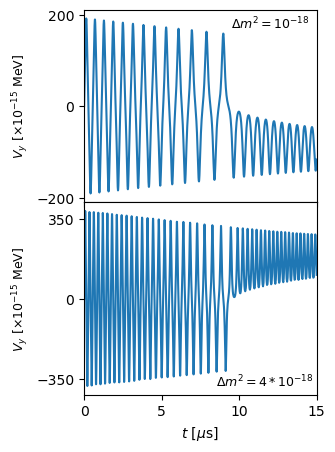

In [27]:
fig, ax = plt.subplots(nrows=2, ncols=1, sharex=True, figsize=(3,5))
plt.subplots_adjust(hspace=0)

ax[0].plot(t_top, Vy_top*1e15)
ax[0].set_yticks([-200,0,200])
ax[0].set_ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=9)
ax[0].text(9.5, 170, r"$\Delta m^2=10^{-18}$", fontsize=9)

ax[1].plot(t_bot, Vy_bot*1e15)
ax[1].set_yticks([-350,0,350])
ax[1].set_xlim(0,15)
ax[1].set_xlabel(r"$t~[\mu\text{s}]$", fontsize=10)
ax[1].set_ylabel(r"$V_y~[\times 10^{-15}~\text{MeV}]$", fontsize=9)
ax[1].text(8.5,-385, r"$\Delta m^2=4*10^{-18}$", fontsize=9)

plt.savefig("VySubplot.pdf", bbox_inches='tight')